# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Lane recap:** CTR-fix / low-CTR-visible-pages. This section turns two already-validated signals into one queue:
- the **Week-4 rule** (`weak_ctr_for_position` — a page is visible, has a real position, and its CTR sits below its position tier's median), and
- the **Week-5/6 Random Forest** (client-grouped holdout, `precision@50 = 0.88`, `ROC AUC = 0.762` — see Week-6 notebook).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)
base_rate = df["is_declining_label"].mean()
print(f"rows: {df.shape[0]:,}  base decline rate: {base_rate:.3f}")

# --- Week-4 baseline rule, verbatim ---
tier_median_ctr = df.groupby("position_tier")["ctr"].transform("median")
df["ctr_gap"] = (tier_median_ctr - df["ctr"]).clip(lower=0)
df["visible"] = (df["impressions_90d"] >= 300).astype(int)
df["has_position"] = (df["avg_position"] > 0).astype(int)
df["weak_ctr"] = ((df["ctr_gap"] > 0) & (df["has_position"] == 1) & (df["visible"] == 1)).astype(int)
df["baseline_score"] = df["visible"] * df["has_position"] * df["ctr_gap"] * np.log1p(df["impressions_90d"])
print(f"weak_ctr_for_position flagged: {df['weak_ctr'].sum():,} / {len(df):,}")

rows: 30,000  base decline rate: 0.542
weak_ctr_for_position flagged: 6,017 / 30,000


In [2]:
# --- Week-5/6 feature matrix + client-grouped split, verbatim (same RANDOM_STATE) ---
numeric_features = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "content_age_days", "days_since_last_update",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
]
categorical_features = ["content_type", "main_intent", "competition_level", "position_tier"]

work = df.copy()
work["has_keyword_data"] = work["search_volume"].notna().astype(int)
work["has_word_count"] = work["word_count"].notna().astype(int)
numeric_features += ["has_keyword_data", "has_word_count"]

num = work[numeric_features].apply(pd.to_numeric, errors="coerce").fillna(0)
cat_encoded = pd.get_dummies(work[categorical_features].fillna("unknown"), drop_first=True)
X = pd.concat([num.reset_index(drop=True), cat_encoded.reset_index(drop=True)], axis=1)
y = df["is_declining_label"].astype(int)

client_ids = df["client_id"].unique()
rng = np.random.default_rng(RANDOM_STATE)
shuffled_clients = rng.permutation(client_ids)
n_test_clients = max(1, int(round(len(shuffled_clients) * 0.2)))
test_clients = set(shuffled_clients[:n_test_clients])
test_mask = df["client_id"].isin(test_clients)

X_train, X_test = X.loc[~test_mask], X.loc[test_mask]
y_train, y_test = y.loc[~test_mask], y.loc[test_mask]

model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=25,
    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

def precision_at_k(labels, scores, k):
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(labels)[order].mean())

proba_test = model.predict_proba(X_test)[:, 1]
p50 = precision_at_k(y_test, proba_test, 50)
auc = roc_auc_score(y_test, proba_test)
print(f"HELD-OUT (validated, {test_mask.sum():,} rows / {len(test_clients)} clients): "
      f"precision@50 = {p50:.3f}  ROC AUC = {auc:.3f}")

# score the whole population; tag which rows the model has actually been validated on
df["model_prob"] = model.predict_proba(X)[:, 1]
df["validation_status"] = np.where(test_mask, "held_out_validated", "in_sample_optimistic")

HELD-OUT (validated, 2,325 rows / 6 clients): precision@50 = 0.880  ROC AUC = 0.762


**A finding that shaped the ranking design, not just a footnote:** sorting the full 30,000-row queue by raw `model_prob` puts **47 of the top 50 rows from `in_sample_optimistic` clients** — pages the model was trained on — and their observed decline rate is 1.00, versus 0.88 for a top-50 built only from `held_out_validated` rows (the number that matches the real, validated precision@50). Mean `model_prob` is also higher in-sample (0.512 vs 0.450) with a higher max (0.889 vs 0.740).

That's the expected shape of in-sample optimism, not a bug — but it means **raw `model_prob` is not safely comparable across the two groups**. Design decision: the queue below ranks by **archetype, then `validation_status` (held-out first), then `model_prob`** — never by raw probability alone across the whole population.

In [3]:
# --- combine the rule + the model into archetypes, actions, reason codes ---
df["model_risk"] = (df["model_prob"] >= 0.5).astype(int)

def archetype(row):
    if row["weak_ctr"] == 1 and row["model_risk"] == 1:
        return "confirmed_ctr_gap"      # both signals agree: real gap, real risk
    if row["weak_ctr"] == 0 and row["model_risk"] == 1:
        return "model_only_risk"        # model sees risk the CTR rule can't see
    if row["weak_ctr"] == 1 and row["model_risk"] == 0:
        return "rule_only_gap"          # rule flags a gap, model is unconvinced
    return "low_priority"

df["archetype"] = df.apply(archetype, axis=1)

action_map = {
    "confirmed_ctr_gap": "refresh_and_review_ctr",
    "model_only_risk": "flag_for_decay_review",
    "rule_only_gap": "review_ctr_and_meta",
    "low_priority": "monitor",
}
df["action"] = df["archetype"].map(action_map)

def reason_codes(row):
    codes = []
    if row["weak_ctr"] == 1: codes.append("weak_ctr_for_position")
    if row["model_risk"] == 1: codes.append("model_decline_risk")
    if row["has_position"] == 0: codes.append("no_position_data")
    if row["visible"] == 0: codes.append("low_visibility")
    return "|".join(codes) if codes else "not_flagged"

df["final_reason_codes"] = df.apply(reason_codes, axis=1)

# ranking: archetype priority -> validated evidence first -> model_prob within that
archetype_priority = {"confirmed_ctr_gap": 0, "model_only_risk": 1, "rule_only_gap": 2, "low_priority": 3}
validation_priority = {"held_out_validated": 0, "in_sample_optimistic": 1}
df["_archetype_pri"] = df["archetype"].map(archetype_priority)
df["_val_pri"] = df["validation_status"].map(validation_priority)
df = df.sort_values(["_archetype_pri", "_val_pri", "model_prob"], ascending=[True, True, False])
df["final_rank"] = np.arange(1, len(df) + 1)

summary = df.groupby("archetype").agg(
    n=("content_id", "size"),
    action=("action", "first"),
    observed_decline_rate=("is_declining_label", "mean"),
).round(3).loc[["confirmed_ctr_gap", "model_only_risk", "rule_only_gap", "low_priority"]]
print(summary)

                       n                  action  observed_decline_rate
archetype                                                              
confirmed_ctr_gap   4345  refresh_and_review_ctr                  0.773
model_only_risk    12868   flag_for_decay_review                  0.705
rule_only_gap       1672     review_ctr_and_meta                  0.359
low_priority       11115                 monitor                  0.291


**Reading the table (observed, this data only):**

| archetype | n | action | observed decline rate |
|---|---:|---|---:|
| `confirmed_ctr_gap` | 4,345 | `refresh_and_review_ctr` | 0.773 |
| `model_only_risk` | 12,868 | `flag_for_decay_review` | 0.705 |
| `rule_only_gap` | 1,672 | `review_ctr_and_meta` | 0.359 |
| `low_priority` | 11,115 | `monitor` | 0.291 |

Both signal-agreement buckets (`confirmed_ctr_gap`, `model_only_risk`) sit well above the 0.542 base rate — **decision-support**, not proof, since this is a same-snapshot association, not a causal test. `rule_only_gap` (rule flags, model doesn't) sits *below* base rate: when the two signals disagree this way, the rule's flag is the less trustworthy one here, so that action stays lower-priority and more human-dependent.

**Cost/value, in plain numbers:** at a ~50-page/week review capacity (the same figure the Week-4 baseline assumed), `confirmed_ctr_gap` alone (4,345 rows across 26 of 32 clients, one client alone holding 1,128) is ~87 review-weeks if worked exhaustively and un-scoped. **This queue is a ranking to work top-down from, per client, not a checklist to clear.**

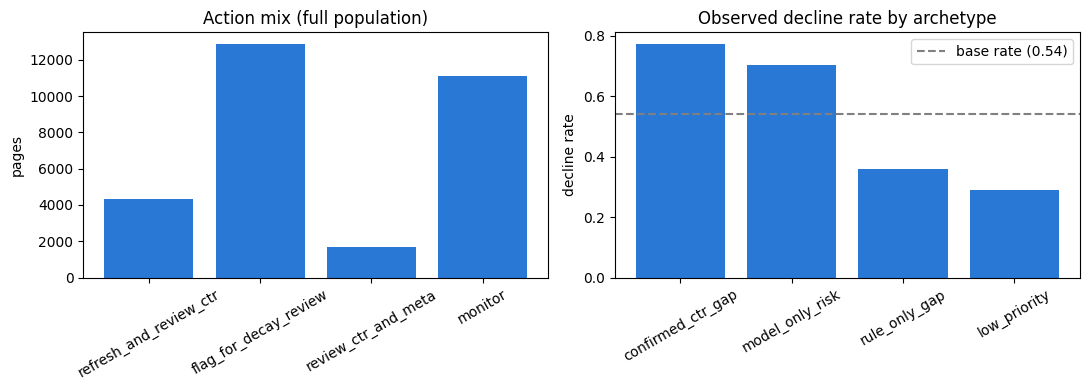

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

action_order = ["refresh_and_review_ctr", "flag_for_decay_review", "review_ctr_and_meta", "monitor"]
counts = df["action"].value_counts().loc[action_order]
axes[0].bar(action_order, counts, color="#2a78d6")
axes[0].set_title("Action mix (full population)")
axes[0].set_ylabel("pages")
axes[0].tick_params(axis="x", rotation=30)

arche_order = ["confirmed_ctr_gap", "model_only_risk", "rule_only_gap", "low_priority"]
rates = summary.loc[arche_order, "observed_decline_rate"]
axes[1].bar(arche_order, rates, color="#2a78d6")
axes[1].axhline(base_rate, color="gray", linestyle="--", label=f"base rate ({base_rate:.2f})")
axes[1].set_title("Observed decline rate by archetype")
axes[1].set_ylabel("decline rate")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.tight_layout()
fig_dir = Path("../figures"); fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "action_mix_and_archetype_rates.png", dpi=150)
plt.show()

In [5]:
cols = ["final_rank", "content_id", "client_id", "archetype", "action", "final_reason_codes",
        "model_prob", "baseline_score", "validation_status", "position_tier", "ctr", "impressions_90d"]
df[cols].head(15)

,final_rank,content_id,client_id,archetype,action,final_reason_codes,model_prob,baseline_score,validation_status,position_tier,ctr,impressions_90d
2871,1,content_071c40cf83c1,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.740053,0.796076,held_out_validated,striking,0.00,1389
3242,2,content_6272bc5f92da,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.727984,0.200576,held_out_validated,page_1,0.13,800
28951,3,content_83be0494c955,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.727217,0.744408,held_out_validated,striking,0.00,868
20830,4,content_575fd096bff5,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.726501,0.640535,held_out_validated,striking,0.00,337
1958,5,content_6e17dbac0491,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.724481,0.660699,held_out_validated,striking,0.00,405
29495,6,content_6f6f29b31462,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.721114,0.549398,held_out_validated,striking,0.04,2561
680,7,content_efce5533859f,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.714538,0.629674,held_out_validated,page_1,0.08,2619
10511,8,content_2ab2467cbe82,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.713425,0.632082,held_out_validated,striking,0.00,312
25913,9,content_331182ca4cae,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.712692,0.240460,held_out_validated,page_3_5,0.00,3026
28713,10,content_3949be886fa2,client_f74efabef1,confirmed_ctr_gap,refresh_and_review_ctr,weak_ctr_for_position|model_decline_risk,0.712303,0.197042,held_out_validated,page_3_5,0.00,711


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a weekly triage aid for a content reviewer/editor working through one client's page inventory — read top-down within a client, use the action + reason codes to decide what to open first. Not a scheduler, not a publishing system, not a scoring API.

**Limits (say them plainly):**
- Trained and validated on the **30,000-row starter CSV, 32 clients only** — not the 79M-row warehouse, not any client outside this set.
- The validated numbers (`precision@50 = 0.88`, `ROC AUC = 0.762`) come from a **6-client held-out test** — directional, not exact to the third decimal (Week-6 finding).
- **`model_prob` is not comparable across `validation_status` groups** (Section 1) — treat `in_sample_optimistic` scores as a weaker signal than the number suggests, even when it's high.
- One 90-day cross-sectional snapshot. No causal claim is supported — "these pages look worth reviewing first, because…" is the honest form, never "refreshing will fix the decline."
- `rule_only_gap` observed decline rate (0.359) is *below* base rate — that action should not be read as equally trustworthy as the other three.

In [6]:
metrics_table = pd.DataFrame([
    {"group": "held_out_validated (real precision@50)", "n": int(test_mask.sum()), "top50_decline_rate": p50, "mean_top50_prob": round(df.loc[df.validation_status=="held_out_validated"].sort_values("model_prob", ascending=False).head(50)["model_prob"].mean(), 3)},
    {"group": "in_sample_optimistic", "n": int((~test_mask).sum()), "top50_decline_rate": round(df.loc[df.validation_status=="in_sample_optimistic"].sort_values("model_prob", ascending=False).head(50)["is_declining_label"].mean(), 3), "mean_top50_prob": round(df.loc[df.validation_status=="in_sample_optimistic"].sort_values("model_prob", ascending=False).head(50)["model_prob"].mean(), 3)},
])
metrics_table

,group,n,top50_decline_rate,mean_top50_prob
0,held_out_validated (real precision@50),2325,0.88,0.712
1,in_sample_optimistic,27675,1.00,0.862


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any row, a human checks:** whether the page's search intent is branded/navigational (low CTR can be normal there); whether the SERP has heavy competing features (ads, a competitor's featured snippet) suppressing clicks structurally; whether the 90-day window caught a seasonal dip; whether `content_type` is one with sparse keyword data (per the data dictionary, missingness follows `content_type` — don't trust a thin row). Same spirit as the Week-4 top-10 review, generalized to every archetype.

**Should NOT be automated — no-go list:**
- No auto-publishing, auto-editing, or auto-pruning content from this queue. Every action is a *review* action, never a *content-change* action.
- No treating `archetype` as a true behavioral segment — it's two thresholded signals combined, not a validated cluster (see `flyrank-context` framing on this).
- No bulk-actioning `confirmed_ctr_gap` or `model_only_risk` client-blind — one client can dominate a bucket (see below), starving the other 25+ clients of review time.
- No comparing `model_prob` across `validation_status` groups, and no deploying against a client outside the original 32 without re-validating.
- No causal language anywhere this queue is shown to a client ("will improve," "is caused by") — decision-support wording only.

In [7]:
conf = df[df.archetype == "confirmed_ctr_gap"]
top_clients = conf["client_id"].value_counts().head(5)
print("confirmed_ctr_gap rows per client (top 5 of", conf['client_id'].nunique(), "clients represented):")
print(top_clients)

weekly_capacity = 50
print(f"\nAt {weekly_capacity}/week, confirmed_ctr_gap alone (n={len(conf):,}) "
      f"is ~{len(conf)/weekly_capacity:.0f} review-weeks if worked un-scoped -- "
      f"work per-client, top-K, not exhaustively.")

confirmed_ctr_gap rows per client (top 5 of 26 clients represented):
client_id
client_19581e27de    1128
client_6208ef0f77     756
client_3fdba35f04     643
client_4e07408562     418
client_7f2253d7e2     255
Name: count, dtype: int64

At 50/week, confirmed_ctr_gap alone (n=4,345) is ~87 review-weeks if worked un-scoped -- work per-client, top-K, not exhaustively.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**The decay/refresh insight:** even `top_3` position pages — the tier that looks healthiest by any current-window metric — show an observed 24.1% decline rate in this snapshot (lowest of the five tiers, but not zero). Week-5's error analysis found the model's most confident *wrong* calls were exactly this pattern: `top_3` pages read as healthy that were actually declining. Strong aggregate 90-day position/traffic signals can mask decline that started recently. **A `monitor` label today is not a permanent label** — it reflects one snapshot.

**Retrain / re-score triggers:**
- The 90-day starter export is refreshed with a new window — re-score, don't reuse old `model_prob`.
- Observed base decline rate drifts materially from ~0.54 (population/composition shift).
- A fresh, manually-labeled sample shows held-out precision@50 dropping meaningfully below ~0.85.
- A new client onboards — cold start, the model has never seen that client's baseline traffic level; treat all their rows as `in_sample_optimistic`-grade at best until re-validated.
- The archetype mix shifts sharply (e.g. `model_only_risk` share moves well past ~43%) — signals the rule and model are drifting apart.

                   n  decline_rate
position_tier                     
top_3           2321         0.241
page_1         11814         0.570
striking        7304         0.610
page_3_5        7242         0.562
deep            1319         0.344


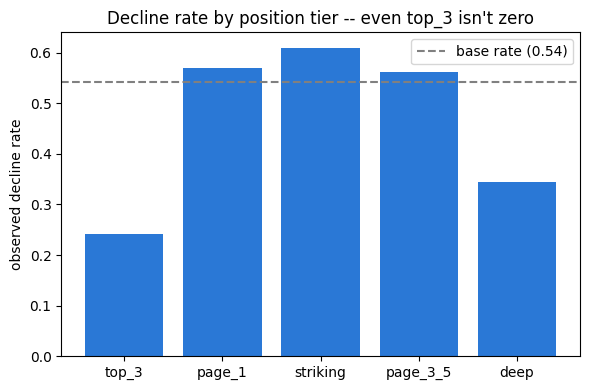

In [8]:
tier_order = ["top_3", "page_1", "striking", "page_3_5", "deep"]
by_tier = df.groupby("position_tier")["is_declining_label"].agg(n="size", decline_rate="mean").loc[tier_order]
print(by_tier.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tier_order, by_tier["decline_rate"], color="#2a78d6")
ax.axhline(base_rate, color="gray", linestyle="--", label=f"base rate ({base_rate:.2f})")
ax.set_ylabel("observed decline rate")
ax.set_title("Decline rate by position tier -- even top_3 isn't zero")
ax.legend()
plt.tight_layout()
plt.savefig(Path("../figures") / "decline_rate_by_position_tier.png", dpi=150)
plt.show()

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [9]:
out_dir = Path("../outputs"); out_dir.mkdir(parents=True, exist_ok=True)

export_cols = [
    "final_rank", "content_id", "client_id", "archetype", "action", "final_reason_codes",
    "model_prob", "baseline_score", "validation_status",
    "position_tier", "ctr", "avg_position", "impressions_90d", "content_type",
]
queue_path = out_dir / "action_playbook_queue.csv"
df[export_cols].to_csv(queue_path, index=False)
print(f"wrote {len(df):,} rows -> {queue_path}")

metrics = {
    "random_state": RANDOM_STATE,
    "n_rows": int(len(df)),
    "n_clients": int(len(client_ids)),
    "n_test_clients": int(len(test_clients)),
    "base_decline_rate": round(float(base_rate), 3),
    "held_out_precision_at_50": round(float(p50), 3),
    "held_out_roc_auc": round(float(auc), 3),
    "archetype_counts": df["archetype"].value_counts().to_dict(),
    "archetype_observed_decline_rate": summary["observed_decline_rate"].to_dict(),
    "action_counts": df["action"].value_counts().to_dict(),
    "top_reason_codes": df["final_reason_codes"].str.split("|").explode().value_counts().head(6).to_dict(),
    "top50_decline_rate_held_out": round(float(metrics_table.loc[0, "top50_decline_rate"]), 3),
    "top50_decline_rate_in_sample": round(float(metrics_table.loc[1, "top50_decline_rate"]), 3),
}
metrics_path = out_dir / "action_playbook_metrics.json"
import json
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"wrote metrics -> {metrics_path}")
print(f"figures saved: {sorted(p.name for p in Path('../figures').glob('*.png'))}")

wrote 30,000 rows -> ..\outputs\action_playbook_queue.csv
wrote metrics -> ..\outputs\action_playbook_metrics.json
figures saved: ['action_mix_and_archetype_rates.png', 'decline_rate_by_position_tier.png']


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.